In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display, clear_output

In [2]:
data_licences = pd.read_parquet("data/data_licences/data_licences.parquet")

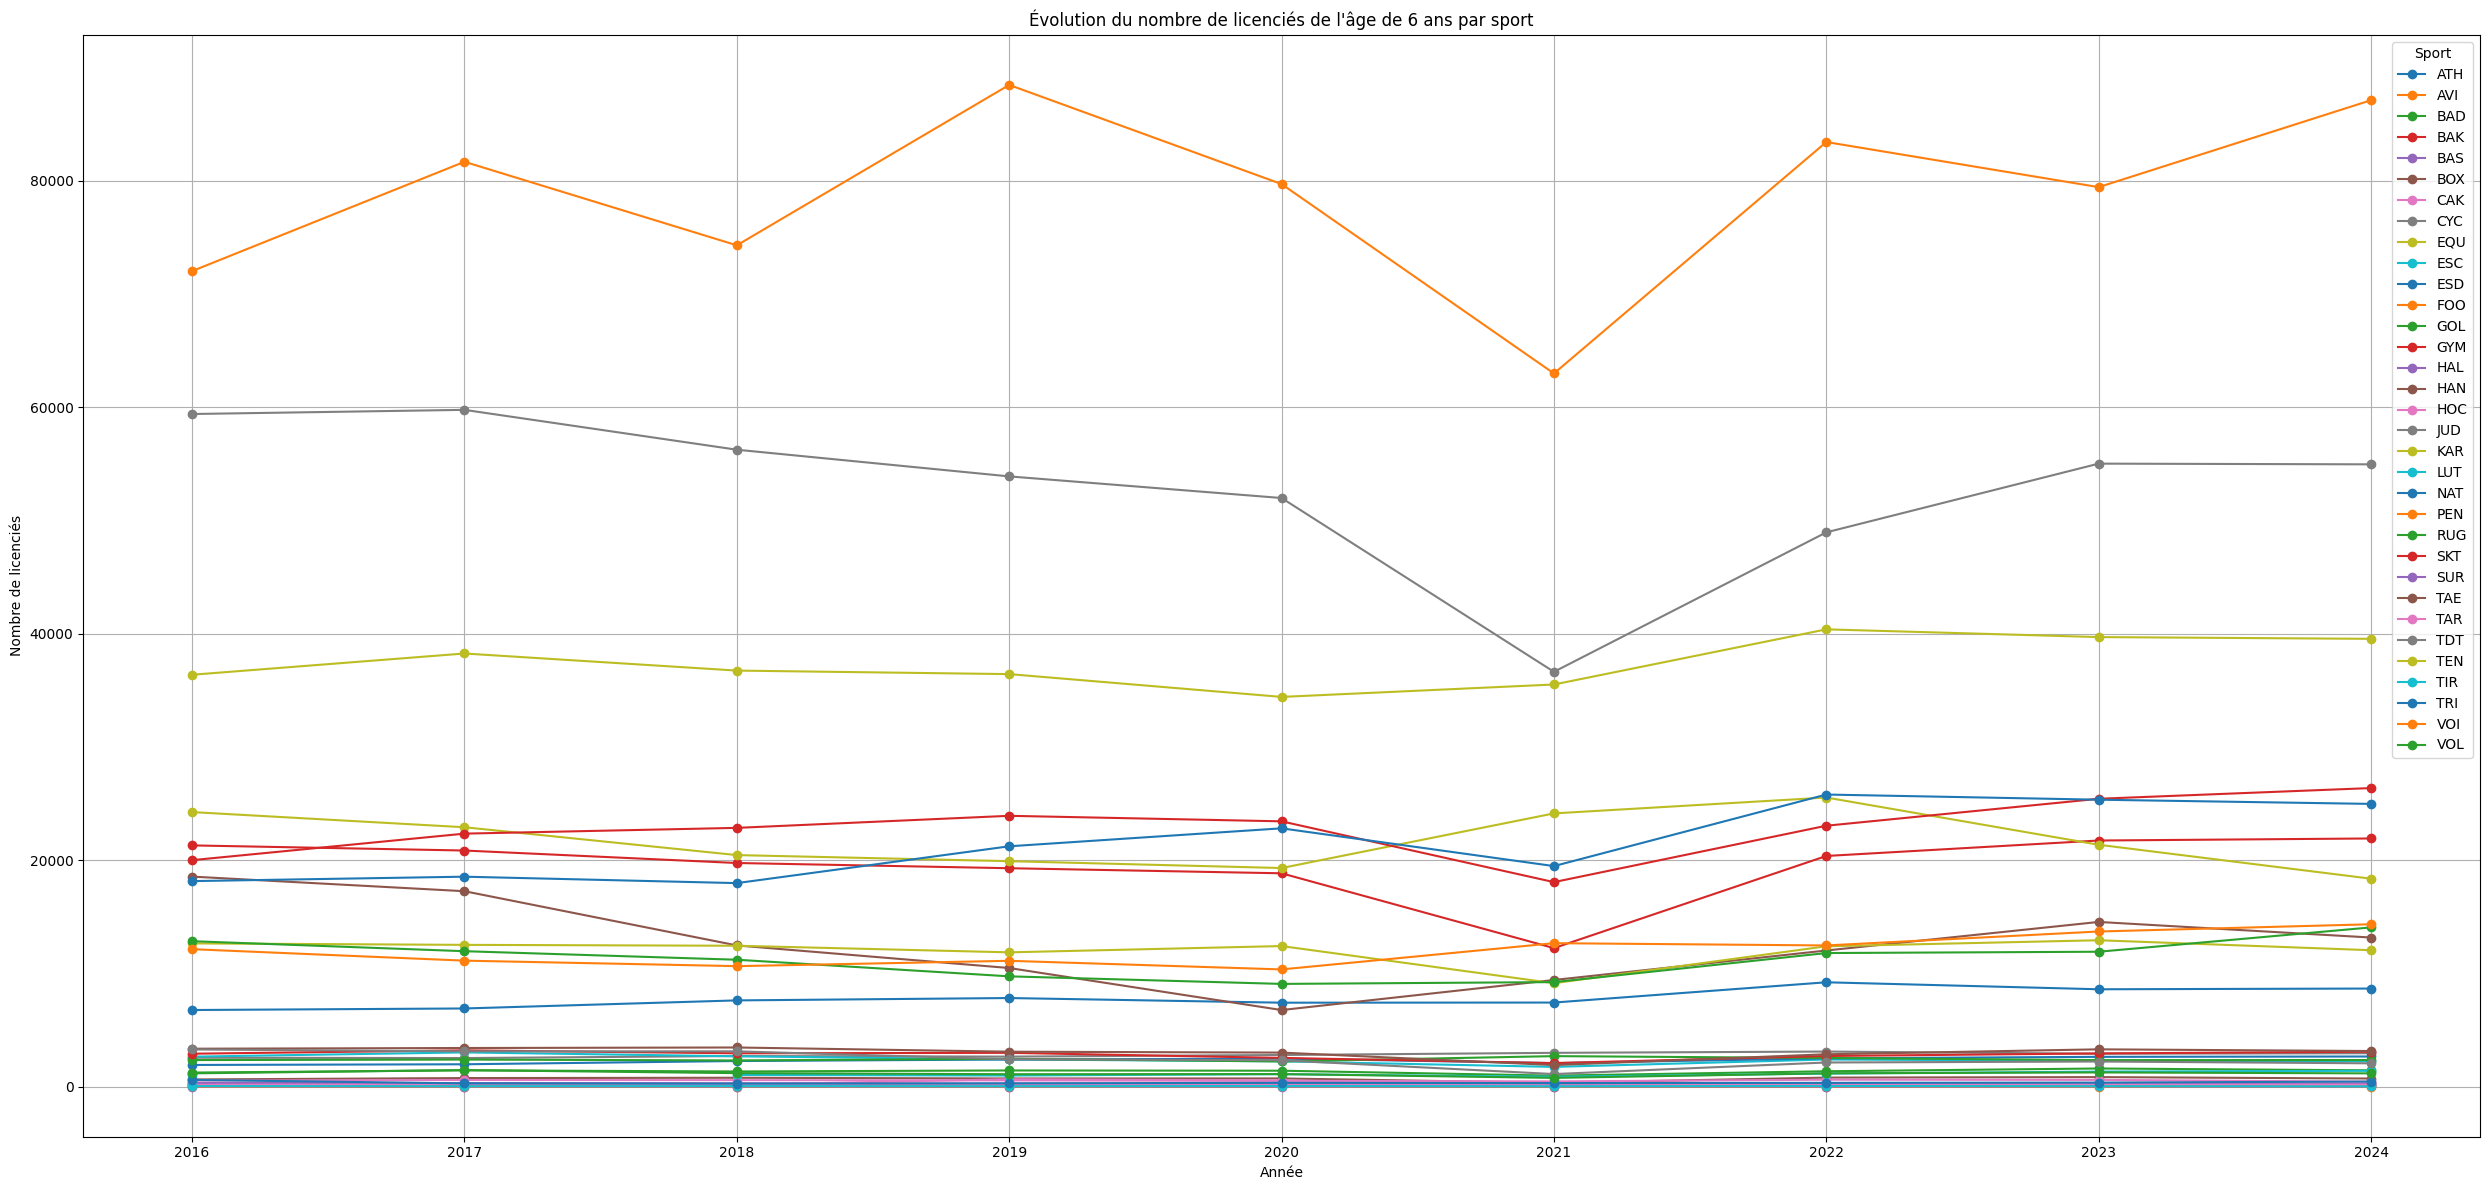

In [3]:
def plot_licencies_age(df, age):
    """ Renvoie un graphique d'évolution des effectifs de licenciés par âge et par sport.

    Paramètres
    ---------
    df (pd.DataFrame) : data frame contenant les données de licences
    age (str) : âge sélectionné
    
    Output
    ---------
    graphique
    """

    df_clean = df[df["code_sport"] != "DIV"]
    df_filtre = df_clean[df_clean["age"] == age]

    table = (
        df_filtre.groupby(["annee", "code_sport"])["licences_annuelles"]
          .sum()
          .unstack()        
          .sort_index()
    )

    plt.figure(figsize=(25, 12))

    for sport in table.columns:
        plt.plot(table.index, table[sport], marker='o', label=sport)

    plt.xlabel("Année")
    plt.ylabel("Nombre de licenciés")
    plt.title(f"Évolution du nombre de licenciés de l'âge de {age} ans par sport")
    plt.legend(title="Sport")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_licencies_age(data_licences, "6")

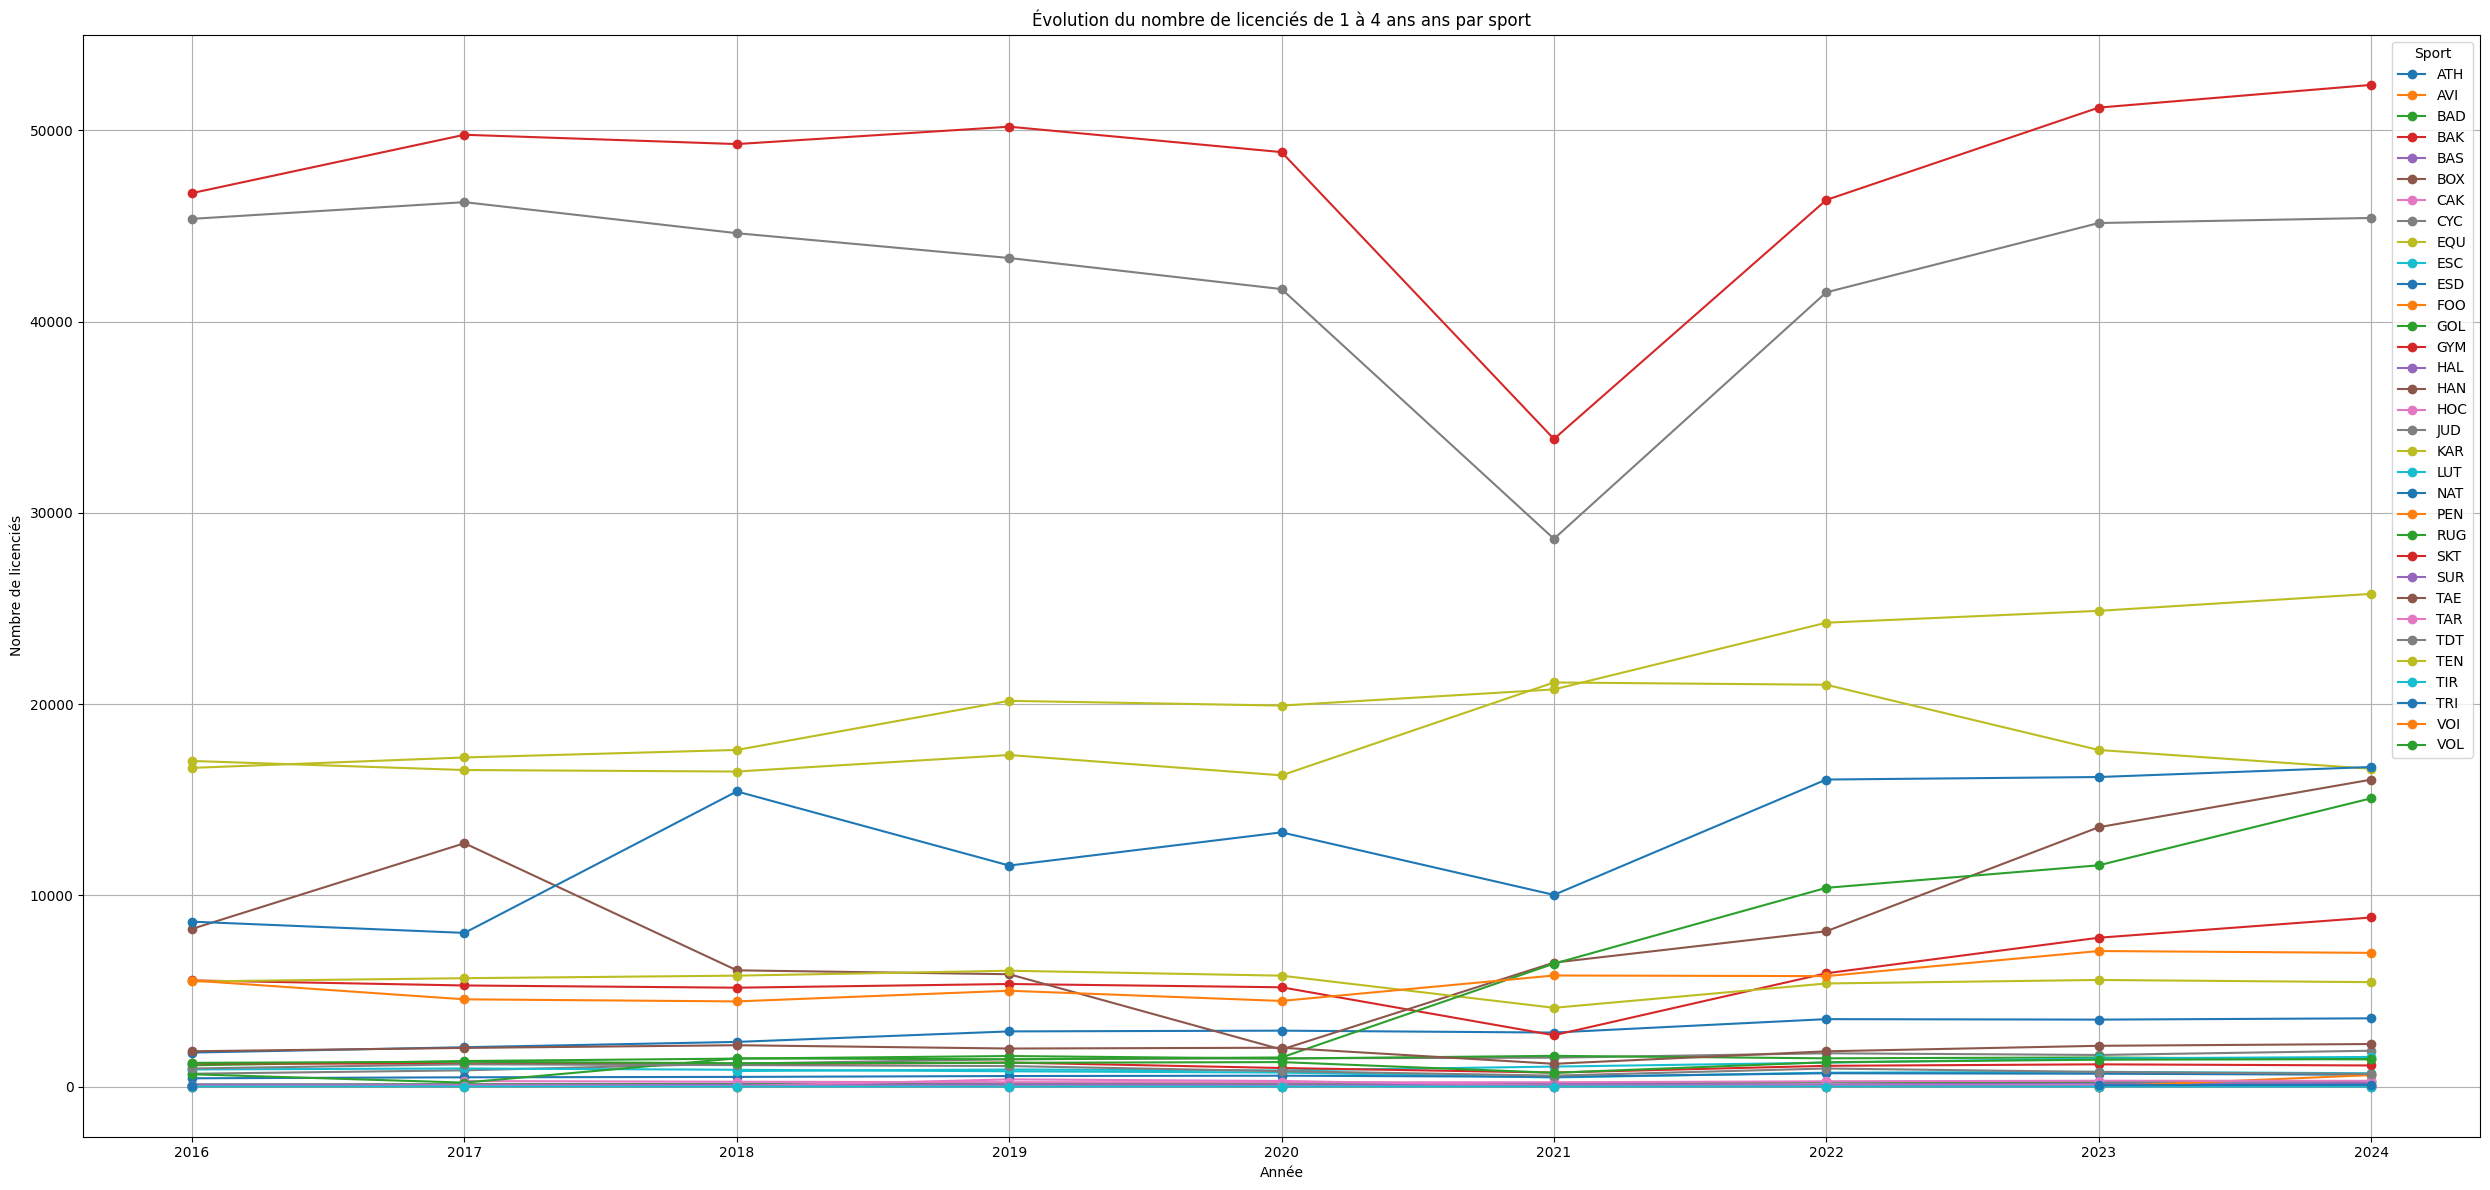

In [4]:
def plot_licencies_age_tranche(df, tranche):
    """ Renvoie un graphique d'évolution des effectifs de licenciés par tranche d'âge et par sport.

    Paramètres
    ---------
    df (pd.DataFrame) : data frame contenant les données de licences
    tranche (str) : tranche d'âge sélectionnée, indexée par des lettres (par exemple "a" pour 1 à 4 ans)
    
    Output
    ---------
    graphique
    """

    df_clean = df[df["code_sport"] != "DIV"]
    df_filtre = df_clean[df_clean["tranche_age"].str[0] == tranche]

    table = (
        df_filtre.groupby(["annee", "code_sport"])["licences_annuelles"]
          .sum()
          .unstack()        
          .sort_index()
    )

    plt.figure(figsize=(25, 12))

    for sport in table.columns:
        plt.plot(table.index, table[sport], marker='o', label=sport)

    plt.xlabel("Année")
    plt.ylabel("Nombre de licenciés")
    plt.title(f"Évolution du nombre de licenciés {df_filtre["tranche_age"].str[4:].unique()[0]} ans par sport")
    plt.legend(title="Sport")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_licencies_age_tranche(data_licences, "a")

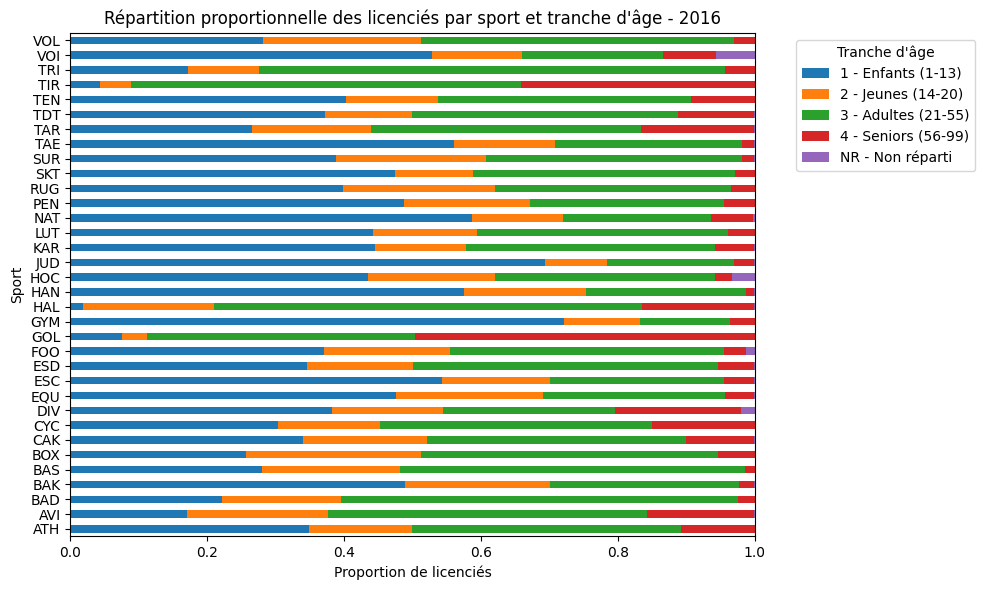

In [5]:
def sport_age_decomposition(df, annee):
    """ Renvoie un graphique décomposant les effectifs de licenciés par tranche d'âge (grande tranche) et par sport pour une année.

    Paramètres
    ---------
    df (pd.DataFrame) : data frame contenant les données de licences
    annee (int) : année sélectionnée
    
    Output
    ---------
    graphique
    """

    df_clean = df[df["annee"] == annee]

    df_pivot = df_clean.pivot_table(
        index='code_sport',
        columns='grande_tranche_age',
        values='licences_annuelles',
        aggfunc='sum',
        fill_value=0
    )

    df_prop = df_pivot.div(df_pivot.sum(axis=1), axis=0)
    
    df_prop.plot(kind='barh', stacked=True, figsize=(10,6))
    
    plt.title(f"Répartition proportionnelle des licenciés par sport et tranche d'âge - {annee}")
    plt.xlabel("Proportion de licenciés")
    plt.ylabel("Sport")
    plt.legend(title="Tranche d'âge", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(0,1)  
    plt.tight_layout()
    plt.show()

sport_age_decomposition(data_licences, 2016)

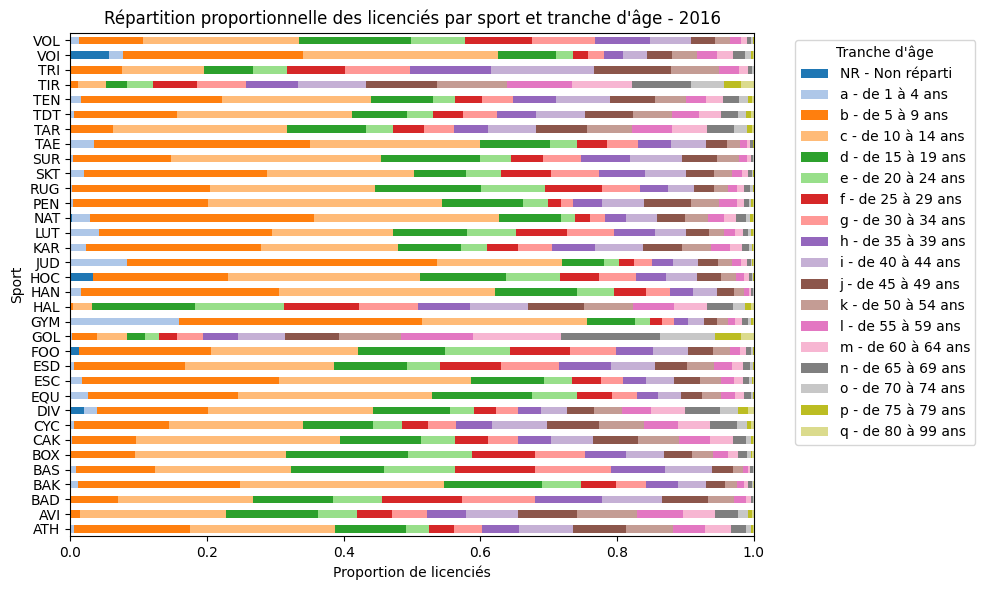

In [6]:
def sport_age_decomposition_fine(df, annee):
    """ Renvoie un graphique décomposant les effectifs de licenciés par tranche d'âge (tranche d'âge fine) et par sport pour une année.

    Paramètres
    ---------
    df (pd.DataFrame) : data frame contenant les données de licences
    annee (int) : année sélectionnée
    
    Output
    ---------
    graphique
    """

    df_clean = df[df["annee"] == annee]

    df_pivot = df_clean.pivot_table(
        index='code_sport',
        columns='tranche_age',
        values='licences_annuelles',
        aggfunc='sum',
        fill_value=0
    )

    df_prop = df_pivot.div(df_pivot.sum(axis=1), axis=0)

    cmap = plt.get_cmap('tab20')
    couleurs = [cmap(i) for i in range(19)]
    
    df_prop.plot(kind='barh', stacked=True, figsize=(10,6), color=couleurs)
    
    plt.title(f"Répartition proportionnelle des licenciés par sport et tranche d'âge - {annee}")
    plt.xlabel("Proportion de licenciés")
    plt.ylabel("Sport")
    plt.legend(title="Tranche d'âge", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(0,1)  
    plt.tight_layout()
    plt.show()

sport_age_decomposition_fine(data_licences, 2016)

In [7]:
# --- Préparer les options pour les widgets ---
ages = sorted(data_licences["age"].dropna().unique())
sports = sorted(data_licences["code_sport"].dropna().unique())
annees = sorted(data_licences["annee"].dropna().unique())

age_widget = widgets.Dropdown(options=ages, description="Âge :", value=ages[0])
sport_widget = widgets.Dropdown(options=["all"] + sports, description="Sport :", value="all")
annee_widget = widgets.Dropdown(options=["all"] + list(annees), description="Année :", value="all")

# --- Fonction pour filtrer et préparer les données ---
def filter_data(df, age, sport, annee):
    df_filtered = df[df["age"] == age]
    
    if sport != "all":
        df_filtered = df_filtered[df_filtered["code_sport"] == sport]
        
    if annee != "all":
        df_filtered = df_filtered[df_filtered["annee"] == annee]
    
    table = (
        df_filtered.groupby(["annee", "code_sport"])["licences_annuelles"]
        .sum()
        .reset_index()
    )
    return table

# --- Fonction pour tracer avec Plotly ---
def plot_licencies_age_interactive(age, sport, annee):
    df_plot = filter_data(data_licences, age, sport, annee)
    if df_plot.empty:
        fig = px.line(title=f"Aucune donnée pour l'âge {age} ans avec ce filtre")
    else:
        fig = px.line(
            df_plot,
            x="annee",
            y="licences_annuelles",
            color="code_sport",
            markers=True,
            title=f"Évolution des licenciés de {age} ans par sport"
        )
    fig.update_layout(
        xaxis_title="Année",
        yaxis_title="Nombre de licenciés",
        legend_title="Sport",
        template="plotly_white"
    )
    fig.show()

# --- Callback pour mettre à jour le graphique ---
def update_graph(change=None):
    clear_output(wait=True)
    display(age_widget, sport_widget, annee_widget)
    plot_licencies_age_interactive(age_widget.value, sport_widget.value, annee_widget.value)

# --- Lier les widgets ---
age_widget.observe(update_graph, names='value')
sport_widget.observe(update_graph, names='value')
annee_widget.observe(update_graph, names='value')

# --- Affichage initial ---
display(age_widget, sport_widget, annee_widget)
update_graph()


Dropdown(description='Âge :', index=26, options=('1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '1…

Dropdown(description='Sport :', options=('all', 'ATH', 'AVI', 'BAD', 'BAK', 'BAS', 'BOX', 'CAK', 'CYC', 'DIV',…

Dropdown(description='Année :', options=('all', np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)…